<a href="https://colab.research.google.com/github/ashifaparveen9725/aimlproject/blob/datavisualization/week1project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('athlete_events.csv', engine='python')

# Filter only medal-winning entries
medals_df = df[df['Medal'].notna()]#returns true if medal is present or false if not

Filtering Medal Winners

After loading the dataset, we focus only on athletes who have won a medal. The column Medal in the dataset contains values such as Gold, Silver, Bronze, or is left blank (NaN) for athletes who did not win any medal.
we remove all rows where the Medal column is empty. This ensures that the new dataframe medals_df contains only entries of athletes who have won at least one medal. This filtered dataset is useful for analyzing medal distributions without including non-medal participants.

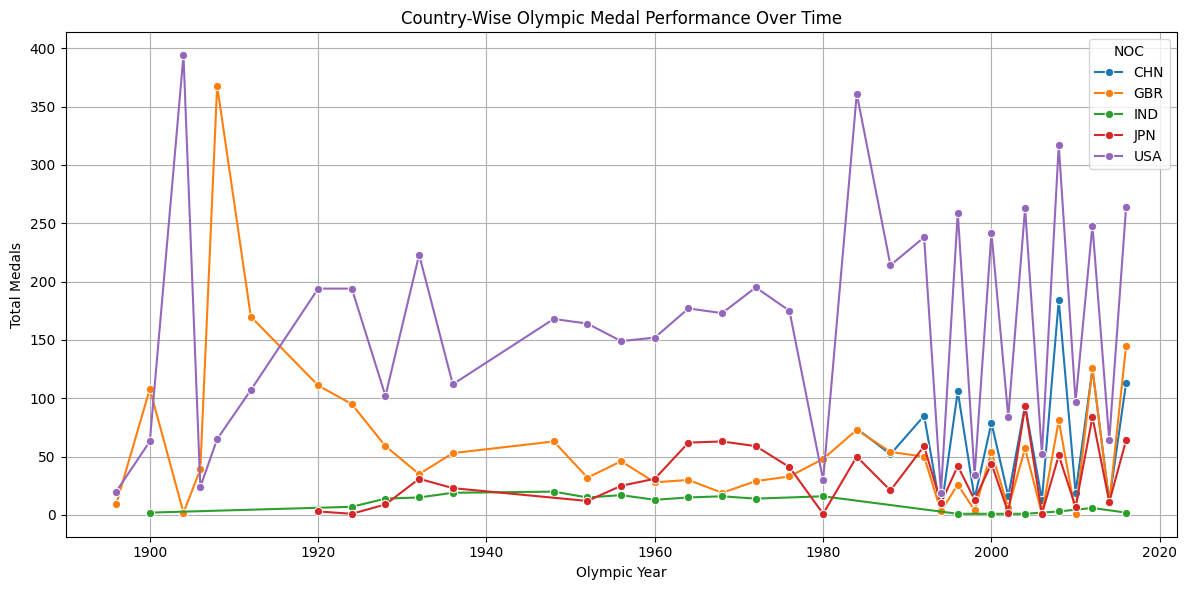

In [16]:
# Group by country and year
country_year_medals = medals_df.groupby(['NOC', 'Year'])['Medal'].count().reset_index()
country_year_medals.rename(columns={'Medal': 'Total_Medals'}, inplace=True)

# Select countries to compare
selected_countries = ['USA', 'CHN', 'IND', 'GBR', 'JPN']
filtered = country_year_medals[country_year_medals['NOC'].isin(selected_countries)]

# Plot
plt.figure(figsize=(12, 6))
sns.lineplot(data=filtered, x='Year', y='Total_Medals', hue='NOC', marker='o')#hue=each country gets its own colour
plt.title('Country-Wise Olympic Medal Performance Over Time')
plt.xlabel('Olympic Year')
plt.ylabel('Total Medals')
plt.grid(True)
plt.tight_layout()#automatically adjust spacing so line doesnt get cut off
plt.show()



*   **Grouping by Country and Year **
 We group the medal dataset by the columns NOC (National Olympic Committee code for each country) and Year. For each group, we count the number of medals won. This gives us the total medal count per country in each Olympic year
*   **Filtering Selected Countries **
 To make the visualization more focused, we filter the dataset to include only a few selected countries: USA, China (CHN), India (IND), Great Britain (GBR), and Japan (JPN).

*  **Plotting Medal Trends**
 We then plot the number of medals won by these countries across different Olympic years using a line plot. Each country is represented by a different color (controlled by the hue parameter), and data points are marked with circles for clarity. Grid lines and automatic spacing adjustments (tight_layout()) are added to improve




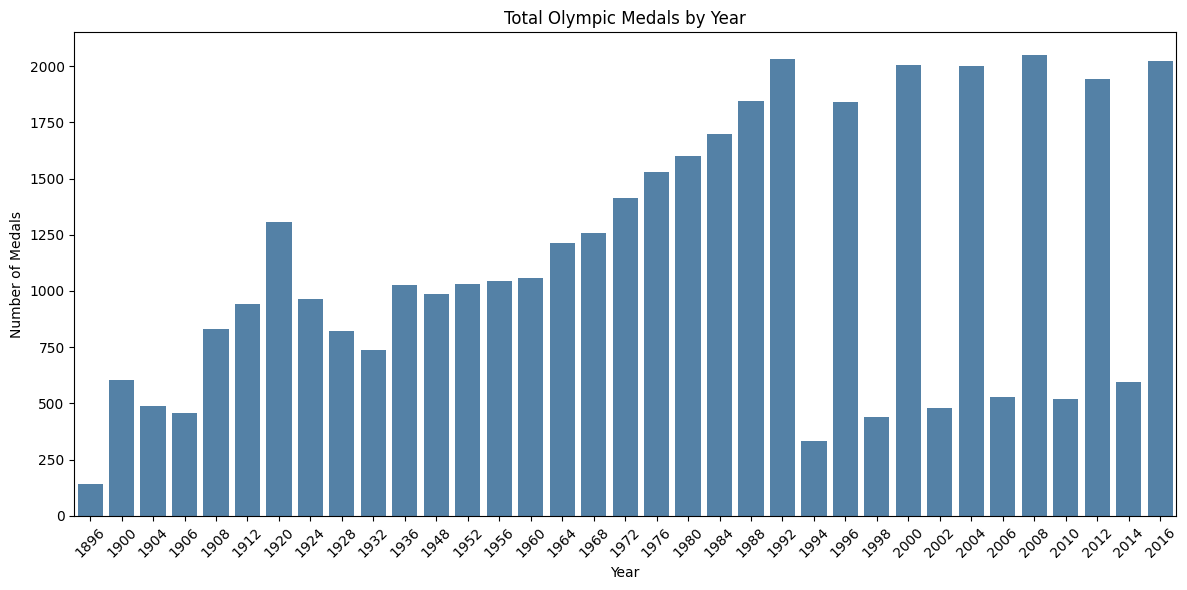

In [17]:
# Total medals per year
yearly_medals = medals_df.groupby('Year')['Medal'].count().reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(data=yearly_medals, x='Year', y='Medal', color='steelblue')
plt.title('Total Olympic Medals by Year')
plt.xticks(rotation=45)
plt.ylabel('Number of Medals')
plt.tight_layout()
plt.show()



*   Grouping by Year
The dataset is grouped by the Year column, and the number of medals awarded in each Olympic year is counted. This gives us the total medal count for every edition of the Games:
*  Bar Plot of Medal Totals
A bar plot is created to visualize how many medals were awarded in each Olympic year. The x-axis represents the Olympic year, while the y-axis shows the corresponding medal count. The bars are displayed in a consistent color (steelblue), and x-axis labels are rotated by 45 degrees for better readability.







/tmp/ipython-input-3891211797.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Medals_Per_Capita', y='NOC', data=top_per_capita, palette='viridis')


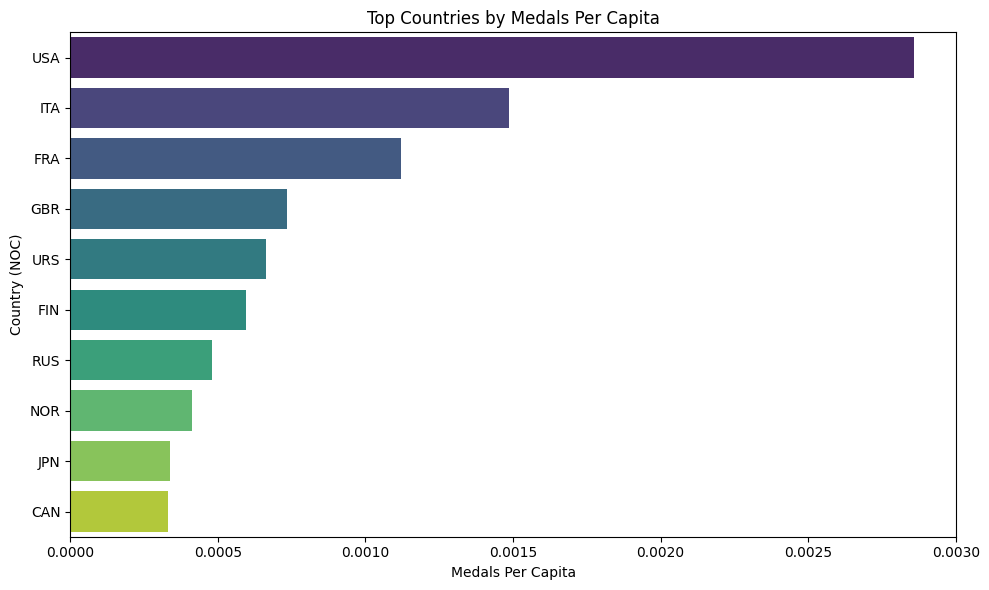

In [18]:
# Total medals per country
country_medals = medals_df.groupby('NOC')['Medal'].count().reset_index(name='Total_Medals')

# Load population data
pop_df = pd.read_csv('noc_regions.csv')  # Columns: NOC, Population

# Merge and calculate medals per capita
merged = pd.merge(country_medals, pop_df, on='NOC', how='left')
merged = merged[merged['population'].notna() & (merged['population'] > 0)]
merged['Medals_Per_Capita'] = merged['Total_Medals'] / merged['population']

# Top countries by medals per capita
top_per_capita = merged.sort_values(by='Medals_Per_Capita', ascending=False).head(10)

# Plot
plt.figure(figsize=(10,6))
sns.barplot(x='Medals_Per_Capita', y='NOC', data=top_per_capita, palette='viridis')
plt.title('Top Countries by Medals Per Capita')
plt.xlabel('Medals Per Capita')
plt.ylabel('Country (NOC)')
plt.tight_layout()
plt.show()

**Medals Per Capita analysis**


*   **Total Medals per Country**
We first group the medal dataset by the NOC (country code) to calculate the total number of medals won by each country
* ** Merging with Population Data**
To normalize performance by population, we load an external dataset (noc_regions.csv) containing country population values. The two datasets are merged on the NOC column. Countries without valid population data (missing or zero) are removed


*   **Calculating Medals Per Capita**
A new metric, Medals_Per_Capita, is computed by dividing each country’s total medal count by its population. This provides a normalized measure of Olympic success relative to country size:
*  **Identifying Top Performers**
Countries are ranked by their medals per capita, and the top 10 countries are selected:


* ** Visualization**
A horizontal bar chart is plotted, showing the top 10 countries by medals per capita.

X-axis → medals per capita (normalized performance).

Y-axis → country codes (NOC).

A viridis color palette is used for visual appeal.







/tmp/ipython-input-2035385608.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_sports, x='Medal', y='Sport', palette='magma')


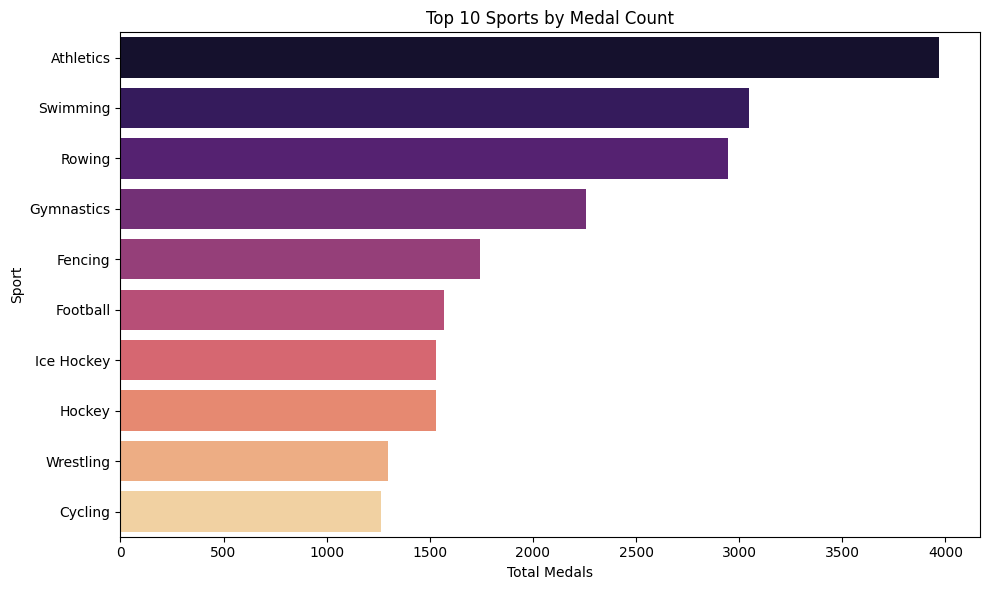

In [19]:
# Total sport by medal count
sport_medals = medals_df.groupby('Sport')['Medal'].count().reset_index()
top_sports = sport_medals.sort_values(by='Medal', ascending=False).head(10)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=top_sports, x='Medal', y='Sport', palette='magma')
plt.title('Top 10 Sports by Medal Count')
plt.xlabel('Total Medals')
plt.tight_layout()
plt.show()

**Top Sports by Medal Count**


*   **Grouping by Sport**
The dataset is grouped by the Sport column, and the number of medals won in each sport is counted. This provides the total medal count per sport:
*   **Selecting the Top 10 Sports**
To focus on the most significant sports, the sports are sorted in descending order of medal count, and only the top 10 sports are selected:


*   **Visualization**
A horizontal bar plot is created to display the top 10 sports by medal count:

X-axis → total number of medals.

Y-axis → sport name.

The magma palette is applied for visual contrast and clarity.




